# Turbofan Engine Predictive Maintenance

This dataset represents sensor and operational data collected from turbofan engines over time to study machine degradation and anticipate failures.
Each engine in the dataset is monitored across multiple operational cycles, where various sensor measurements and operating conditions are recorded.
The goal is to analyze how the engine s performance changes over time and identify patterns that may indicate potential failure.

This is a benchmark dataset used for predicting the "Remaining Useful Life" (RUL) of aircraft engines.

Data is recorded sequentially over time

* Each engine starts at cycle = 1 and continues until a certain cycle.
* As cycles increase, the engine gradually degrades.
* Sensor values may show trends or patterns indicating this degradation.

In [3]:
import pandas as pd

df = pd.read_csv("tbf_engine.txt", sep=" ", header=None)
df.head()

,0,1,2,3,4,5,6,7,8,9,...,18,19,20,21,22,23,24,25,26,27
0,1,1,0.0023,0.0003,100.0,518.67,643.02,1585.29,1398.21,14.62,...,8125.55,8.4052,0.03,392,2388,100.0,38.86,23.3735,NaN,NaN
1,1,2,-0.0027,-0.0003,100.0,518.67,641.71,1588.45,1395.42,14.62,...,8139.62,8.3803,0.03,393,2388,100.0,39.02,23.3916,NaN,NaN
2,1,3,0.0003,0.0001,100.0,518.67,642.46,1586.94,1401.34,14.62,...,8130.10,8.4441,0.03,393,2388,100.0,39.08,23.4166,NaN,NaN
3,1,4,0.0042,0.0000,100.0,518.67,642.44,1584.12,1406.42,14.62,...,8132.90,8.3917,0.03,391,2388,100.0,39.00,23.3737,NaN,NaN
4,1,5,0.0014,0.0000,100.0,518.67,642.51,1587.19,1401.92,14.62,...,8129.54,8.4031,0.03,390,2388,100.0,38.99,23.4130,NaN,NaN


This is how dataset looks now   
specifying column names and converting to csv

In [12]:
df = df.dropna(axis=1)

columns = ['engine_id', 'cycle'] + \
          [f'setting{i}' for i in range(1,4)] + \
          [f'sensor{i}' for i in range(1,22)]

df.columns = columns

In [13]:
df.head()

,engine_id,cycle,setting1,setting2,setting3,sensor1,sensor2,sensor3,sensor4,sensor5,...,sensor12,sensor13,sensor14,sensor15,sensor16,sensor17,sensor18,sensor19,sensor20,sensor21
0,1,1,0.0023,0.0003,100.0,518.67,643.02,1585.29,1398.21,14.62,...,521.72,2388.03,8125.55,8.4052,0.03,392,2388,100.0,38.86,23.3735
1,1,2,-0.0027,-0.0003,100.0,518.67,641.71,1588.45,1395.42,14.62,...,522.16,2388.06,8139.62,8.3803,0.03,393,2388,100.0,39.02,23.3916
2,1,3,0.0003,0.0001,100.0,518.67,642.46,1586.94,1401.34,14.62,...,521.97,2388.03,8130.10,8.4441,0.03,393,2388,100.0,39.08,23.4166
3,1,4,0.0042,0.0000,100.0,518.67,642.44,1584.12,1406.42,14.62,...,521.38,2388.05,8132.90,8.3917,0.03,391,2388,100.0,39.00,23.3737
4,1,5,0.0014,0.0000,100.0,518.67,642.51,1587.19,1401.92,14.62,...,522.15,2388.03,8129.54,8.4031,0.03,390,2388,100.0,38.99,23.4130


The dataset contains 21 anonymized sensor readings. The exact physical meaning of each sensor is not explicitly provided, as the data is derived from a simulated engine model.

Therefore, in this analysis, sensors are treated as abstract features representing various internal engine parameters. The focus is on identifying patterns, trends, and relationships between these features and engine performance over time.

In [14]:
mapping=pd.read_csv("engine_metadata_mapping.csv")
mapping_dict=dict(zip(mapping['Column'],mapping['Technical Name']))

df.rename(columns=mapping_dict,inplace=True)


In [15]:
df.head()

,engine_id,cycle,Altitude,Mach Number,Throttle Resolver Angle,Total temperature at fan inlet,Total temperature at LPC outlet,Total temperature at HPC outlet,Total temperature at LPT outlet,Pressure at fan inlet,...,Ratio of fuel flow to Ps30,Corrected fan speed,Corrected core speed,Bypass Ratio,Burner fuel-air ratio,Bleed Enthalpy,Demanded fan speed,Demanded corrected fan speed,HPT coolant bleed,LPT coolant bleed
0,1,1,0.0023,0.0003,100.0,518.67,643.02,1585.29,1398.21,14.62,...,521.72,2388.03,8125.55,8.4052,0.03,392,2388,100.0,38.86,23.3735
1,1,2,-0.0027,-0.0003,100.0,518.67,641.71,1588.45,1395.42,14.62,...,522.16,2388.06,8139.62,8.3803,0.03,393,2388,100.0,39.02,23.3916
2,1,3,0.0003,0.0001,100.0,518.67,642.46,1586.94,1401.34,14.62,...,521.97,2388.03,8130.10,8.4441,0.03,393,2388,100.0,39.08,23.4166
3,1,4,0.0042,0.0000,100.0,518.67,642.44,1584.12,1406.42,14.62,...,521.38,2388.05,8132.90,8.3917,0.03,391,2388,100.0,39.00,23.3737
4,1,5,0.0014,0.0000,100.0,518.67,642.51,1587.19,1401.92,14.62,...,522.15,2388.03,8129.54,8.4031,0.03,390,2388,100.0,38.99,23.4130


In [16]:
df.to_csv("clean_engine_data.csv", index=False)

In [23]:
!pip install duckdb

   ---------------------------------------- 0.0/13.1 MB ? eta -:--:--
   ---------------------------------------- 0.0/13.1 MB ? eta -:--:--
   ---------------------------------------- 0.0/13.1 MB ? eta -:--:--
   ---------------------------------------- 0.0/13.1 MB ? eta -:--:--
    --------------------------------------- 0.3/13.1 MB ? eta -:--:--
    --------------------------------------- 0.3/13.1 MB ? eta -:--:--
   - -------------------------------------- 0.5/13.1 MB 477.7 kB/s eta 0:00:27
   - -------------------------------------- 0.5/13.1 MB 477.7 kB/s eta 0:00:27
   - -------------------------------------- 0.5/13.1 MB 477.7 kB/s eta 0:00:27
   - -------------------------------------- 0.5/13.1 MB 477.7 kB/s eta 0:00:27
   - -------------------------------------- 0.5/13.1 MB 477.7 kB/s eta 0:00:27
   - -------------------------------------- 0.5/13.1 MB 477.7 kB/s eta 0:00:27
   - -------------------------------------- 0.5/13.1 MB 477.7 kB/s eta 0:00:27
   - ----------------------

In [36]:
import duckdb
import pandas as pd
df = pd.read_csv('clean_engine_data.csv')

## NASA originally designed this to develop algorithms for Prognostics and Health Management (PHM).
### The overarching question NASA asked was: "Can we predict exactly when an engine will fail based on its sensor history?"

***1.Fleet Lifespan analysis***

In [65]:
query="""WITH engine_lifespans AS (SELECT 
    engine_id, 
    MAX(cycle) AS total_cycles
FROM df
GROUP BY engine_id    
)
SELECT 
    AVG(total_cycles) AS average_life,
    MIN(total_cycles) AS shortest_life,
    MAX(total_cycles) AS longest_life,
    COUNT(engine_id) AS total_engines
FROM engine_lifespans;"""

result=duckdb.query(query).to_df()
print(result)

   average_life  shortest_life  longest_life  total_engines
0        130.96             31           303            100


By implementing a safety buffer before the earliest failure (31 cycles) and using the average life (131 cycles) as a benchmark,   
we address the fleet s high variability (272-cycle gap),   
proving that sensor-driven insights are more reliable for maintenance than engine age alone.

***2.Calculating Remaining Useful Life(RUL)***

In [66]:
query1="""SELECT 
    engine_id,
    cycle,
    (MAX(cycle) OVER(PARTITION BY engine_id)) - cycle AS RUL
FROM df
ORDER BY engine_id, cycle;"""
result1=duckdb.query(query1).to_df()
result1.head()

,engine_id,cycle,RUL
0,1,1,30
1,1,2,29
2,1,3,28
3,1,4,27
4,1,5,26


The RUL calculation provides a precise countdown to failure for every flight cycle,
transforming the raw data into a target label for ***predictive maintenance modeling***

***3.Identifying Flat-line Sensors***

In [67]:
df = pd.read_csv('clean_engine_data.csv')

stds = df.std()

print(stds.sort_values()) 

Demanded corrected fan speed       0.000000e+00
Throttle Resolver Angle            0.000000e+00
Demanded fan speed                 0.000000e+00
Burner fuel-air ratio              8.823140e-15
Engine pressure ratio              3.157595e-13
Pressure at fan inlet              2.671743e-12
Total temperature at fan inlet     6.014263e-11
Mach Number                        2.940306e-04
Total pressure in bypass-duct      1.704085e-03
Altitude                           2.202685e-03
Bypass Ratio                       2.900933e-02
Corrected fan speed                5.693431e-02
Physical fan speed                 5.744178e-02
LPT coolant bleed                  8.412028e-02
HPT coolant bleed                  1.416808e-01
Static pressure at HPC outlet      1.959172e-01
Total temperature at LPC outlet    4.008993e-01
Ratio of fuel flow to Ps30         5.596268e-01
Total pressure at HPC outlet       6.812861e-01
Bleed Enthalpy                     1.233577e+00
Total temperature at HPC outlet    5.003

In [68]:
query = """
SELECT * EXCLUDE (
    "Total temperature at fan inlet",
    "Demanded fan speed",
    "Demanded corrected fan speed",
    "Throttle Resolver Angle"
) FROM df

"""
new_clean_data=duckdb.query(query).to_df()
new_clean_data.head()

,engine_id,cycle,Altitude,Mach Number,Total temperature at LPC outlet,Total temperature at HPC outlet,Total temperature at LPT outlet,Pressure at fan inlet,Total pressure in bypass-duct,Total pressure at HPC outlet,...,Engine pressure ratio,Static pressure at HPC outlet,Ratio of fuel flow to Ps30,Corrected fan speed,Corrected core speed,Bypass Ratio,Burner fuel-air ratio,Bleed Enthalpy,HPT coolant bleed,LPT coolant bleed
0,1,1,0.0023,0.0003,643.02,1585.29,1398.21,14.62,21.61,553.90,...,1.3,47.20,521.72,2388.03,8125.55,8.4052,0.03,392,38.86,23.3735
1,1,2,-0.0027,-0.0003,641.71,1588.45,1395.42,14.62,21.61,554.85,...,1.3,47.50,522.16,2388.06,8139.62,8.3803,0.03,393,39.02,23.3916
2,1,3,0.0003,0.0001,642.46,1586.94,1401.34,14.62,21.61,554.11,...,1.3,47.50,521.97,2388.03,8130.10,8.4441,0.03,393,39.08,23.4166
3,1,4,0.0042,0.0000,642.44,1584.12,1406.42,14.62,21.61,554.07,...,1.3,47.28,521.38,2388.05,8132.90,8.3917,0.03,391,39.00,23.3737
4,1,5,0.0014,0.0000,642.51,1587.19,1401.92,14.62,21.61,554.16,...,1.3,47.31,522.15,2388.03,8129.54,8.4031,0.03,390,38.99,23.4130


In [69]:
dead_sensors = [
    'Total temperature at fan inlet', 
    'Demanded fan speed', 
    'Demanded corrected fan speed', 
    'Throttle Resolver Angle'
]
df_cleaned = df.drop(columns=dead_sensors)

***4.Sensor Degradation and Moving Averages***

In [70]:
query1 = """
SELECT 
    engine_id,
    cycle,
    "Total pressure at HPC outlet",
    
    AVG("Total pressure at HPC outlet") OVER(
        PARTITION BY engine_id 
        ORDER BY cycle 
        ROWS BETWEEN 9 PRECEDING AND CURRENT ROW
    ) AS hpc_pressure_moving_avg
FROM df_cleaned
ORDER BY engine_id, cycle 
"""


result = duckdb.sql(query1).df()
result.head(15)

,engine_id,cycle,Total pressure at HPC outlet,hpc_pressure_moving_avg
0,1,1,553.90,553.900000
1,1,2,554.85,554.375000
2,1,3,554.11,554.286667
3,1,4,554.07,554.232500
4,1,5,554.16,554.218000
5,1,6,554.22,554.218333
6,1,7,553.89,554.171429
7,1,8,553.59,554.098750
8,1,9,554.49,554.142222
9,1,10,554.28,554.156000


Transformed jagged, noisy signals into clear "Trend Drifts."
This allows us to see an engine wearing out cycles before a raw sensor spike would occur.

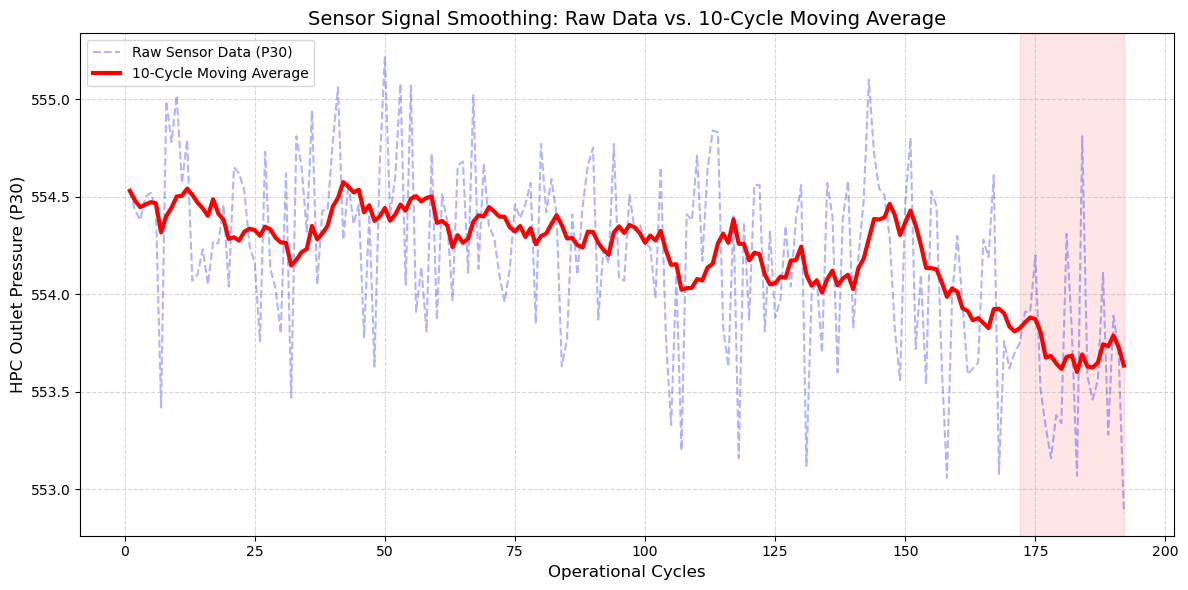

In [73]:
import matplotlib.pyplot as plt

sample_engine = result[result['engine_id'] == 10]

plt.figure(figsize=(12, 6))

# Raw Sensor Data
plt.plot(sample_engine['cycle'], sample_engine['Total pressure at HPC outlet'], 
         label='Raw Sensor Data (P30)', alpha=0.3, color='blue', linestyle='--')

# Moving Average
plt.plot(sample_engine['cycle'], sample_engine['hpc_pressure_moving_avg'], 
         label='10-Cycle Moving Average', color='red', linewidth=3)

plt.title('Sensor Signal Smoothing: Raw Data vs. 10-Cycle Moving Average', fontsize=14)
plt.xlabel('Operational Cycles', fontsize=12)
plt.ylabel('HPC Outlet Pressure (P30)', fontsize=12)
plt.grid(True, linestyle='--', alpha=0.5)
plt.legend(loc='best')

# Danger Zone
last_cycle = sample_engine['cycle'].max()
plt.axvspan(last_cycle-20, last_cycle, color='red', alpha=0.1, label='Failure Zone (Last 20 Cycles)')

plt.tight_layout()
plt.show()

***5.Danger Zone***

In [71]:

query5 = """
WITH engine_status AS (
    SELECT 
        *,
        (MAX(cycle) OVER(PARTITION BY engine_id) - cycle) AS RUL
    FROM df_cleaned
)
SELECT 
    CASE 
        WHEN RUL <= 20 THEN '1. DANGER (RUL <= 20)'
        WHEN RUL > 150 THEN '2. HEALTHY (RUL > 150)'
        ELSE '3. NORMAL'
    END AS maintenance_status,
    -- Step 2: Calculate averages for key sensors
    ROUND(AVG("Total temperature at HPC outlet"), 2) AS avg_hpc_temp,
    ROUND(AVG("Total pressure at HPC outlet"), 2) AS avg_hpc_pressure,
    ROUND(AVG("Static pressure at HPC outlet"), 2) AS avg_static_pressure,
    COUNT(*) AS data_points
FROM engine_status
WHERE maintenance_status IN ('1. DANGER (RUL <= 20)', '2. HEALTHY (RUL > 150)')
GROUP BY maintenance_status
ORDER BY maintenance_status;
"""

result5 = duckdb.sql(query5).df()
result5

,maintenance_status,avg_hpc_temp,avg_hpc_pressure,avg_static_pressure,data_points
0,1. DANGER (RUL <= 20),1590.64,553.32,47.55,2100
1,2. HEALTHY (RUL > 150),1586.05,554.13,47.30,1247


These are the threshold values derived 

***6.Operational Setting Impact***

In [74]:

query6 = """
WITH engine_summary AS (
    SELECT 
        engine_id, 
        MAX(cycle) AS max_life,
        AVG(Altitude) AS avg_altitude
    FROM df_cleaned
    GROUP BY engine_id
),
bucketed_engines AS (
    SELECT 
        *,
        NTILE(3) OVER(ORDER BY avg_altitude) AS altitude_bucket
    FROM engine_summary
)
SELECT 
    CASE 
        WHEN altitude_bucket = 1 THEN 'Low Altitude'
        WHEN altitude_bucket = 2 THEN 'Medium Altitude'
        ELSE 'High Altitude'
    END AS flight_profile,
    ROUND(AVG(max_life), 2) AS avg_fleet_lifespan,
    COUNT(*) AS num_engines
FROM bucketed_engines
GROUP BY altitude_bucket
ORDER BY altitude_bucket;
"""

result6 = duckdb.sql(query6).df()
result6

,flight_profile,avg_fleet_lifespan,num_engines
0,Low Altitude,138.29,34
1,Medium Altitude,140.94,33
2,High Altitude,113.42,33


The data reveals that engines operating at High Altitudes have a significantly shorter lifespan.     
This is likely because thinner air at high altitudes requires the engine to run at higher internal temperatures to maintain thrust.   

Medium Altitude flight profile tends out to be most efficient if altitude can be compromised.   

## OUTCOME SUMMARY 


1. Fleet Lifespan Analysis: Determined that the average engine lifecycle is 131 cycles, 
establishing a baseline for scheduling routine maintenance across the fleet.

2. RUL Ground Truth: Calculated Remaining Useful Life (RUL) using SQL window functions,
transforming raw time-series data into a labeled dataset for predictive modeling.

3. Feature Engineering & Noise Reduction: Identified 4 "flat-line" sensors (Zero Variance)
and removed them to improve model efficiency. Applied 10-cycle Moving Averages to smooth sensor "jitter",
reveling clear degradation trends.

4. Health Thresholds (The "Danger Zone"): Established that an increase of 0.29% in HPC Temperature
and a decrease of 0.15% in HPC Pressure are statistically significant markers that an engine has entered its final 20 cycles.

5. Operational Impact: Discovered a "High-Altitude Penalty", where engines operating at
high altitudes exhibit an 18% shorter lifespan than those at low altitudes, justifying usage-based maintenance schedules.